In [62]:
import numpy as np
import torch    
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss

In [63]:
#X_raw = np.load('X_raw.npy')
X_feat = np.load('X_feat.npy')
X_feat_12 = np.load('X_feat_12.npy')
Y = np.load('Y.npy')

from sklearn.impute import SimpleImputer
imputer   = SimpleImputer(strategy='mean')
X_feat_12 = imputer.fit_transform(X_feat_12)


# Mismo random_state para que el test sea idéntico en ambos
#X_train_raw,  X_test_raw,  Y_train, Y_test = train_test_split(X_raw,  Y, test_size=0.2, random_state=42)
X_train_feat, X_test_feat, _,       _      = train_test_split(X_feat, Y, test_size=0.2, random_state=42)
X_train_feat_12, X_test_feat_12, Y_train, Y_test = train_test_split(X_feat_12, Y, test_size=0.2, random_state=42)

#scaler_raw  = StandardScaler()
#X_train_raw  = scaler_raw.fit_transform(X_train_raw)
#X_test_raw   = scaler_raw.transform(X_test_raw)

scaler_feat = StandardScaler()
X_train_feat = scaler_feat.fit_transform(X_train_feat)
X_test_feat  = scaler_feat.transform(X_test_feat)

#print(f"Shape X_raw:  {X_raw.shape}")
#print(f"Shape X_feat: {X_feat.shape}")

#print(f"Raw  → train: {X_train_raw.shape}  | test: {X_test_raw.shape}")
print(f"Feat → train: {X_train_feat.shape} | test: {X_test_feat.shape}")

scaler_feat_12 = StandardScaler()
X_train_feat_12 = scaler_feat_12.fit_transform(X_train_feat_12)
X_test_feat_12  = scaler_feat_12.transform(X_test_feat_12)
print(f"Shape X_feat_12: {X_feat_12.shape}")
print(f"Feat_12 → train: {X_train_feat_12.shape} | test: {X_test_feat_12.shape}")

Feat → train: (13587, 40) | test: (3397, 40)
Shape X_feat_12: (16984, 458)
Feat_12 → train: (13587, 458) | test: (3397, 458)


In [64]:
ENFERMEDADES = ['NORM', 'STTC', 'CD', 'MI', 'HYP']

In [109]:
#Vamos a ajustar el valor de los umbrales por cada enfermedad en funcion de como de critico sea no detectarla (falsos negativos) o detectarla erroneamente (falsos positivos). En este caso, es mas importante reducir los falsos negativos, asi que bajamos el umbral. Esto se puede hacer de forma automatica con tecnicas como ROC o Precision-Recall, pero lo haremos manualmente para entenderlo mejor.
UMBRAL = {
    'NORM': 0.5, #No queremos diagnosticar a un paciente enfermo como sano (NORM), asi que ponemos un umbral mas alto para reducir falsos positivos.
    'STTC': 0.5, #Representa alteraciones del segmento ST/T, que pueden indicar isquemia o infarto. Es importante detectarlas, pero no queremos demasiados falsos positivos, asi que ponemos un umbral intermedio.
    'CD':   0.5, #Suelen ser detectables de forma razonablemente fiable, asi que ponemos un umbral equilibrado para mantener estabilidad en precision y recall.
    'MI':   0.50, #Patología crítica donde un falso negativo puede tener consecuencias graves, asi que bajamos el umbral para priorizar la detección (recall) incluso a costa de aumentar falsos positivos.
    'HYP':  0.50 #Tiene una relevancia clínica importante, pero no tan crítica como el infarto, asi que ponemos un umbral intermedio para mantener un buen equilibrio entre precision y recall.
}

In [65]:
import numpy as np

for i in range(Y.shape[1]):
    num_ones = np.sum(Y[:, i] == 1)
    num_zeros = np.sum(Y[:, i] == 0)
    
    print(f"Enfermedad {ENFERMEDADES[i]}: {num_ones+num_zeros}")
    print(f"  1s (positivos): {num_ones}")
    print(f"  0s (negativos): {num_zeros}")
    print()

Enfermedad NORM: 16984
  1s (positivos): 4157
  0s (negativos): 12827

Enfermedad STTC: 16984
  1s (positivos): 7132
  0s (negativos): 9852

Enfermedad CD: 16984
  1s (positivos): 4339
  0s (negativos): 12645

Enfermedad MI: 16984
  1s (positivos): 2145
  0s (negativos): 14839

Enfermedad HYP: 16984
  1s (positivos): 3868
  0s (negativos): 13116



In [66]:
def mostrar_matrices(nombre, Y_true, Y_pred):
    mcm = multilabel_confusion_matrix(Y_true, Y_pred)
    fig, axes = plt.subplots(1, len(ENFERMEDADES), figsize=(4 * len(ENFERMEDADES), 4))
    fig.suptitle(f"Matrices de confusión — {nombre}", fontsize=13)
    for i, (ax, clase) in enumerate(zip(axes, ENFERMEDADES)):
        tn, fp, fn, tp = mcm[i].ravel()
        matriz = np.array([[tp, fn], [fp, tn]])
        ax.imshow(matriz, cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred Pos', 'Pred Neg'], fontsize=9)
        ax.set_yticklabels(['Real Pos', 'Real Neg'], fontsize=9)
        ax.set_title(clase, fontsize=11)
        for row in range(2):
            for col in range(2):
                ax.text(col, row, str(matriz[row, col]),
                        ha='center', va='center', fontsize=12,
                        color='white' if matriz[row, col] > matriz.max() / 2 else 'black')
    plt.tight_layout()
    plt.show()

In [94]:
def ejecutar_logistic_regression(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== Logistic Regression — {nombre} ===")
    model = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'), n_jobs=-1)
    model.fit(X_train, Y_train)

    #predecimos probabilidades para ajustar el threshold y reducir los falsos negativos
    Y_prob_test  = model.predict_proba(X_test)
    Y_prob_train = model.predict_proba(X_train)

    #threshold = 0.3  # 👈 BAJARLO reduce falsos negativos

    #Y_pred_test  = (Y_prob_test >= threshold).astype(int)
    #Y_pred_train = (Y_prob_train >= threshold).astype(int)

    #Ajuste con threshold específico para cada enfermedad
    Y_pred_test = np.zeros_like(Y_prob_test)
    Y_pred_train = np.zeros_like(Y_prob_train)

    for i, enf in enumerate(ENFERMEDADES):
        Y_pred_test[:, i]  = (Y_prob_test[:, i]  >= UMBRAL[enf])
        Y_pred_train[:, i] = (Y_prob_train[:, i] >= UMBRAL[enf])

    
    print("\n--- Train ---")
    hamming = 1 - hamming_loss(Y_train, model.predict(X_train))
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_train, Y_pred_train, zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    hamming = 1 - hamming_loss(Y_test, model.predict(X_test))
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_test, Y_pred_test, zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"LR — {nombre}", Y_test, Y_pred_test)
    return model


def ejecutar_random_forest(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== Random Forest — {nombre} ===")
    model = RandomForestClassifier(
        n_estimators=300, #cambio de 200 a 300
        max_depth=10, #Cambio de 20 a 10 para evitar el overfitting
        min_samples_leaf=10,#Cabio de 5 a 10 para evitar tener arboles tan finos (menos ruido-> mejor test) 
        random_state=42, 
        class_weight='balanced',
        max_features='sqrt', #Cambio de 'auto' a 'sqrt' para reducir la correlación entre árboles y mejorar la generalización
        n_jobs=-1)
    model.fit(X_train, Y_train)

    Y_prob_test = np.array([
        proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
        for proba in model.predict_proba(X_test)
        ]).T

    Y_prob_train = np.array([
        proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
        for proba in model.predict_proba(X_train)
        ]).T

    #threshold más bajo para reducir FN
    #threshold = 0.3  # 👈 AJUSTABLE

    # convertir a 0/1
    #Y_pred_test  = (Y_prob_test >= threshold).astype(int)
    #Y_pred_train = (Y_prob_train >= threshold).astype(int)

    Y_pred_test = np.zeros_like(Y_prob_test)
    Y_pred_train = np.zeros_like(Y_prob_train)

    for i, enf in enumerate(ENFERMEDADES):
        Y_pred_test[:, i]  = (Y_prob_test[:, i]  >= UMBRAL[enf])
        Y_pred_train[:, i] = (Y_prob_train[:, i] >= UMBRAL[enf])

    
    print("\n--- Train ---")
    hamming = 1 - hamming_loss(Y_train, model.predict(X_train))
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_train, Y_pred_train, zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    hamming = 1 - hamming_loss(Y_test, model.predict(X_test))
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_test, Y_pred_test, zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"RF — {nombre}", Y_test, Y_pred_test)
    return model


def ejecutar_mlp(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== MLP — {nombre} ===")

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

    train_loader      = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True)
    train_eval_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=False)
    test_loader       = DataLoader(TensorDataset(X_test_t, torch.zeros(len(X_test_t))), batch_size=32, shuffle=False)

    total      = Y_train.shape[0]
    pos_counts = Y_train.sum(axis=0)
    neg_counts = total - pos_counts
    pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32)

    class MLP(nn.Module):
        def __init__(self, input_size, output_size):
            super().__init__()
            self.red = nn.Sequential(
                nn.Linear(input_size, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3), #No overfitting
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, output_size)
            )
        def forward(self, x):
            return self.red(x)

    model     = MLP(input_size=X_train.shape[1], output_size=Y_train.shape[1])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    EPOCHS    = 100
    PACIENCIA = 15
    mejor_perdida     = float('inf')
    epochs_sin_mejora = 0
    mejor_estado      = None

    for epoch in range(EPOCHS):
        model.train()
        perdida_total = 0
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()
            perdida_total += loss.item()

        perdida_media = perdida_total / len(train_loader)
        scheduler.step(perdida_media)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - Pérdida: {perdida_media:.4f} - lr: {optimizer.param_groups[0]['lr']:.6f}")

        if perdida_media < mejor_perdida - 0.001:
            mejor_perdida     = perdida_media
            epochs_sin_mejora = 0
            mejor_estado      = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= PACIENCIA:
                print(f"  Early stopping en epoch {epoch+1}")
                break

    model.load_state_dict(mejor_estado)
    model.eval()


    def predecir(loader):
        preds = []
        with torch.no_grad():
            for X_batch, _ in loader:
                #preds.append((torch.sigmoid(model(X_batch)) >= 0.3).float())# El threshold se baja aquí de 0.5 a 0.3 para reducir falsos negativos
                prob = torch.sigmoid(model(X_batch)).numpy()
                pred = np.zeros_like(prob)
                for i, enf in enumerate(ENFERMEDADES):
                    pred[:, i] = (prob[:, i] >= UMBRAL[enf])
                preds.append(pred)
        return np. vstack(preds)#torch.cat(preds).numpy()

    Y_pred_train = predecir(train_eval_loader)
    Y_pred_test  = predecir(test_loader)
    
    print("\n--- Train ---")
    hamming = 1 - hamming_loss(Y_train, Y_pred_train)
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_train, Y_pred_train, zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    hamming = 1 - hamming_loss(Y_test, Y_pred_test)
    print(f"Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):{hamming:.4f}")
    print(classification_report(Y_test, Y_pred_test, zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"MLP — {nombre}", Y_test, Y_pred_test)
    return model

In [95]:
print(f"NaN en X_feat_12: {np.isnan(X_feat_12).sum()}")
print(f"Pacientes con NaN: {np.isnan(X_feat_12).any(axis=1).sum()}")

NaN en X_feat_12: 0
Pacientes con NaN: 0



=== Logistic Regression — Features ===

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.7479
              precision    recall  f1-score   support

        NORM       0.50      0.81      0.62      3323
        STTC       0.72      0.83      0.78      5711
          CD       0.43      0.72      0.53      3447
          MI       0.29      0.70      0.41      1729
         HYP       0.49      0.65      0.56      3111

   micro avg       0.50      0.76      0.61     17321
   macro avg       0.49      0.74      0.58     17321
weighted avg       0.54      0.76      0.62     17321
 samples avg       0.56      0.74      0.61     17321

--- Test ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.7426
              precision    recall  f1-score   support

        NORM       0.48      0.78      0.60       834
        STTC       0.72      0.83      0.77      1421
          CD       0.43      0.72      0.54       892
          MI

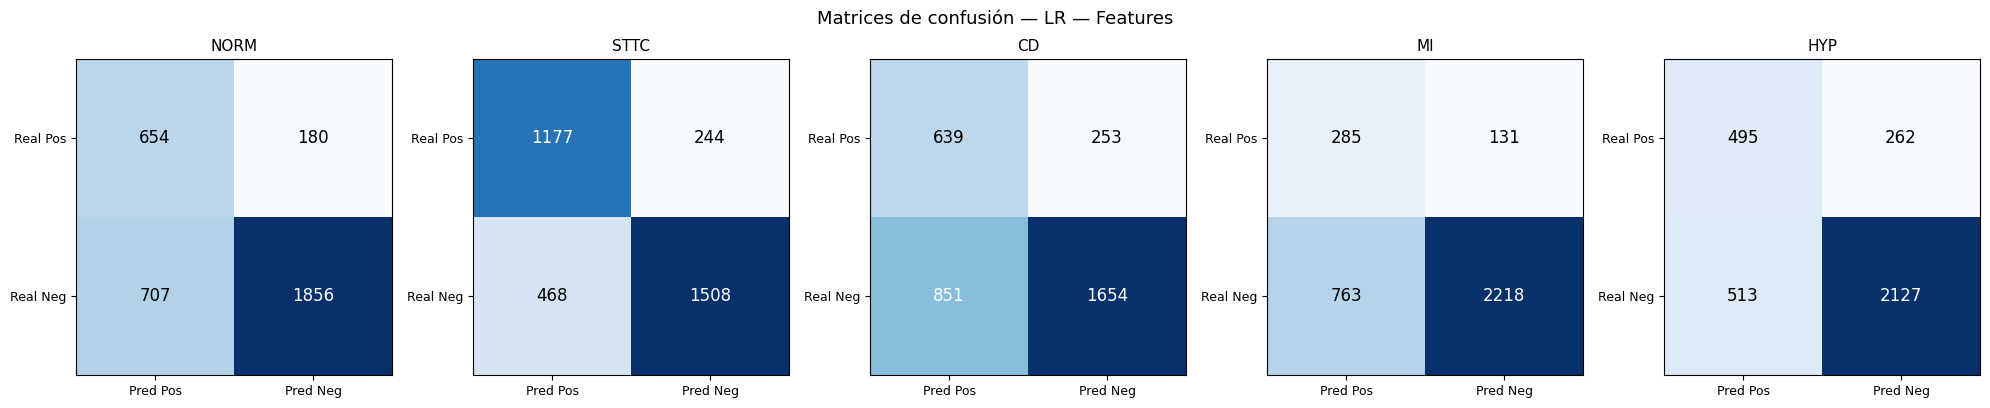


=== Logistic Regression — Features_12 ===

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8433
              precision    recall  f1-score   support

        NORM       0.62      0.87      0.72      3323
        STTC       0.81      0.90      0.85      5711
          CD       0.58      0.81      0.67      3447
          MI       0.46      0.84      0.59      1729
         HYP       0.66      0.78      0.72      3111

   micro avg       0.65      0.85      0.73     17321
   macro avg       0.62      0.84      0.71     17321
weighted avg       0.66      0.85      0.74     17321
 samples avg       0.69      0.84      0.73     17321

--- Test ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8322
              precision    recall  f1-score   support

        NORM       0.59      0.86      0.70       834
        STTC       0.79      0.89      0.83      1421
          CD       0.57      0.76      0.65       892
         

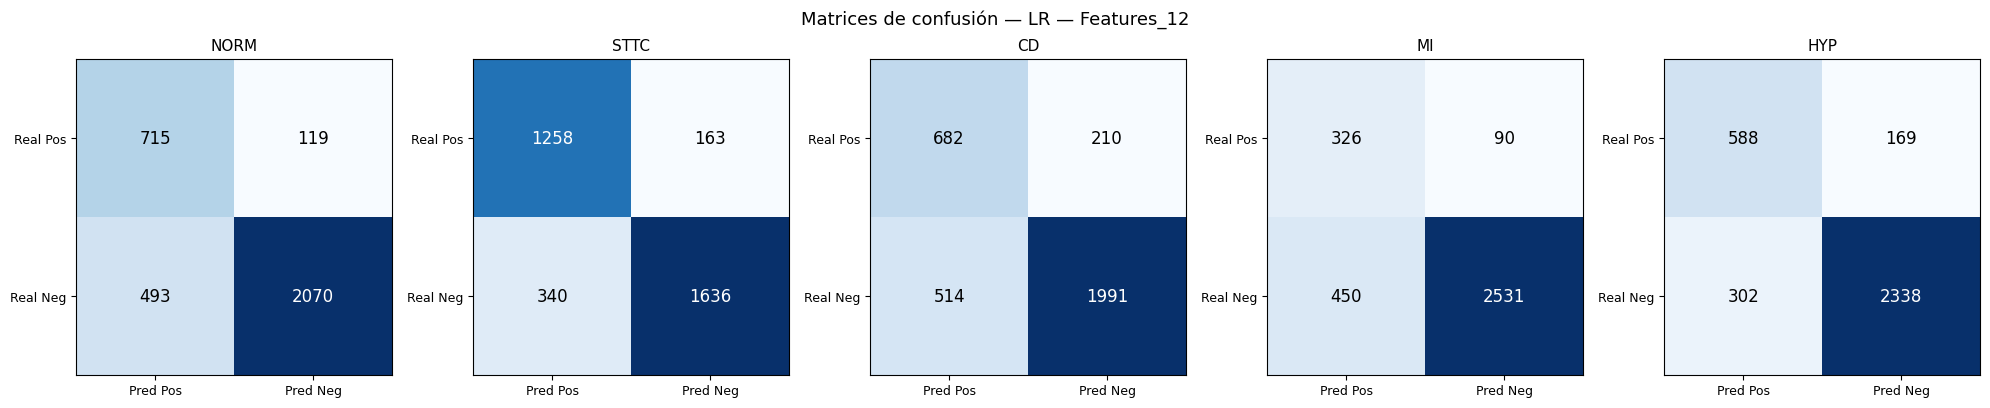

In [110]:
#lr_raw  = ejecutar_logistic_regression(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
lr_feat = ejecutar_logistic_regression(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
lr_feat_12 = ejecutar_logistic_regression(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")


=== Random Forest — Features ===

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8090
              precision    recall  f1-score   support

        NORM       0.60      0.76      0.67      3323
        STTC       0.92      0.31      0.46      5711
          CD       0.67      0.58      0.62      3447
          MI       0.48      0.77      0.59      1729
         HYP       0.70      0.58      0.63      3111

   micro avg       0.65      0.55      0.59     17321
   macro avg       0.67      0.60      0.60     17321
weighted avg       0.72      0.55      0.58     17321
 samples avg       0.41      0.47      0.42     17321

--- Test ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.7714
              precision    recall  f1-score   support

        NORM       0.53      0.71      0.61       834
        STTC       0.90      0.28      0.42      1421
          CD       0.53      0.47      0.50       892
          MI      

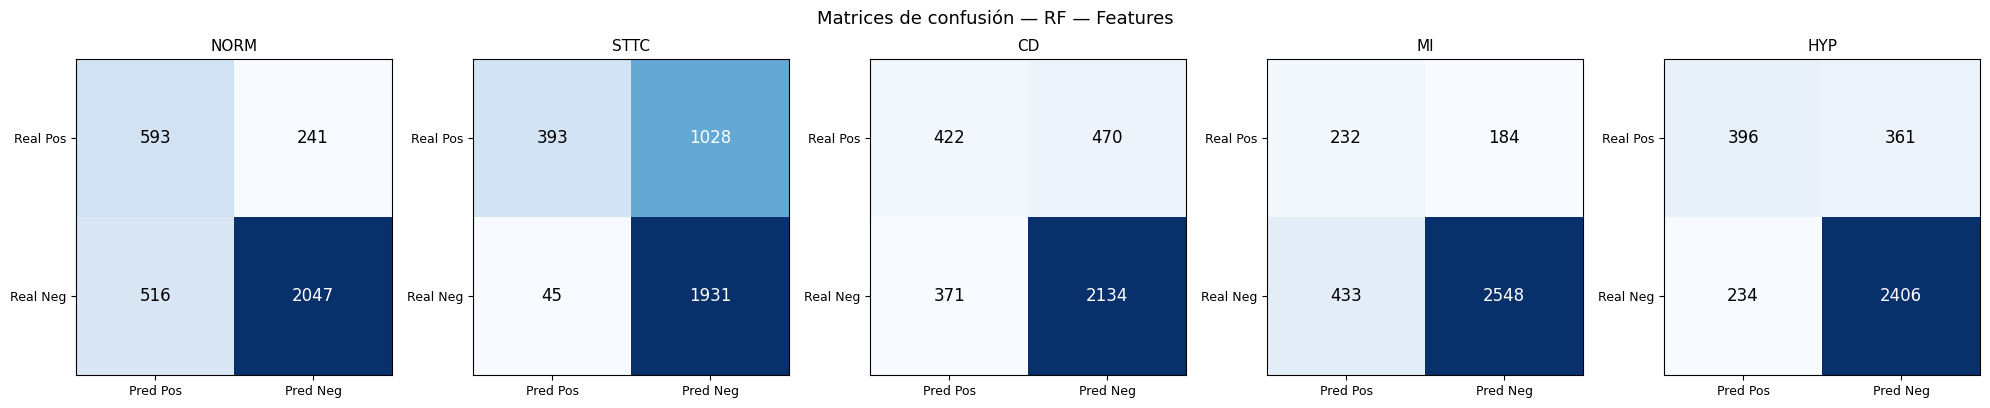


=== Random Forest — Features_12 ===

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8654
              precision    recall  f1-score   support

        NORM       0.71      0.81      0.76      3323
        STTC       0.94      0.50      0.66      5711
          CD       0.77      0.72      0.75      3447
          MI       0.62      0.87      0.72      1729
         HYP       0.76      0.74      0.75      3111

   micro avg       0.76      0.69      0.72     17321
   macro avg       0.76      0.73      0.73     17321
weighted avg       0.80      0.69      0.72     17321
 samples avg       0.59      0.62      0.59     17321

--- Test ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8327
              precision    recall  f1-score   support

        NORM       0.63      0.74      0.68       834
        STTC       0.93      0.48      0.63      1421
          CD       0.65      0.61      0.63       892
          MI   

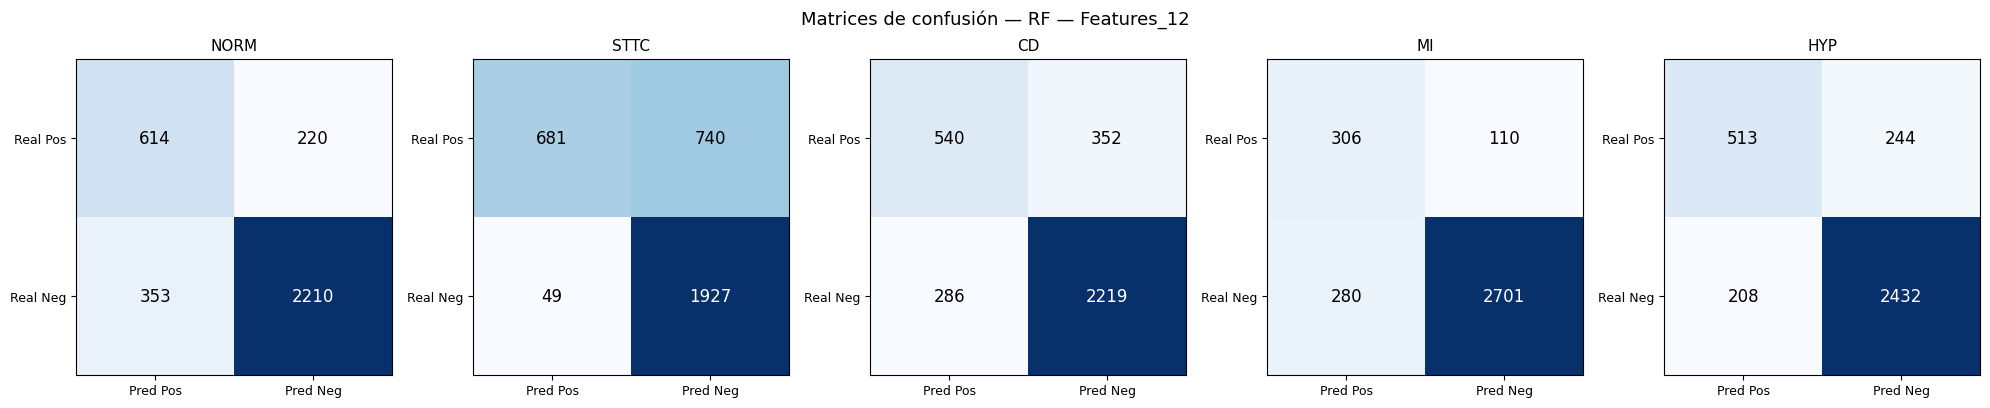

In [111]:
#rf_raw  = ejecutar_random_forest(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
rf_feat = ejecutar_random_forest(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
rf_feat_12 = ejecutar_random_forest(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")


=== MLP — Features ===
  Epoch 10/100 - Pérdida: 0.7633 - lr: 0.001000
  Epoch 20/100 - Pérdida: 0.7470 - lr: 0.001000
  Epoch 30/100 - Pérdida: 0.7417 - lr: 0.001000
  Epoch 40/100 - Pérdida: 0.7310 - lr: 0.001000
  Epoch 50/100 - Pérdida: 0.7216 - lr: 0.001000
  Epoch 60/100 - Pérdida: 0.7113 - lr: 0.000500
  Epoch 70/100 - Pérdida: 0.7059 - lr: 0.000500
  Epoch 80/100 - Pérdida: 0.6993 - lr: 0.000500
  Epoch 90/100 - Pérdida: 0.6983 - lr: 0.000500
  Epoch 100/100 - Pérdida: 0.6941 - lr: 0.000500

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.8019
              precision    recall  f1-score   support

        NORM       0.58      0.85      0.69      3323
        STTC       0.73      0.93      0.82      5711
          CD       0.52      0.77      0.62      3447
          MI       0.36      0.85      0.51      1729
         HYP       0.59      0.69      0.63      3111

   micro avg       0.58      0.83      0.68     17321
   macro avg       0

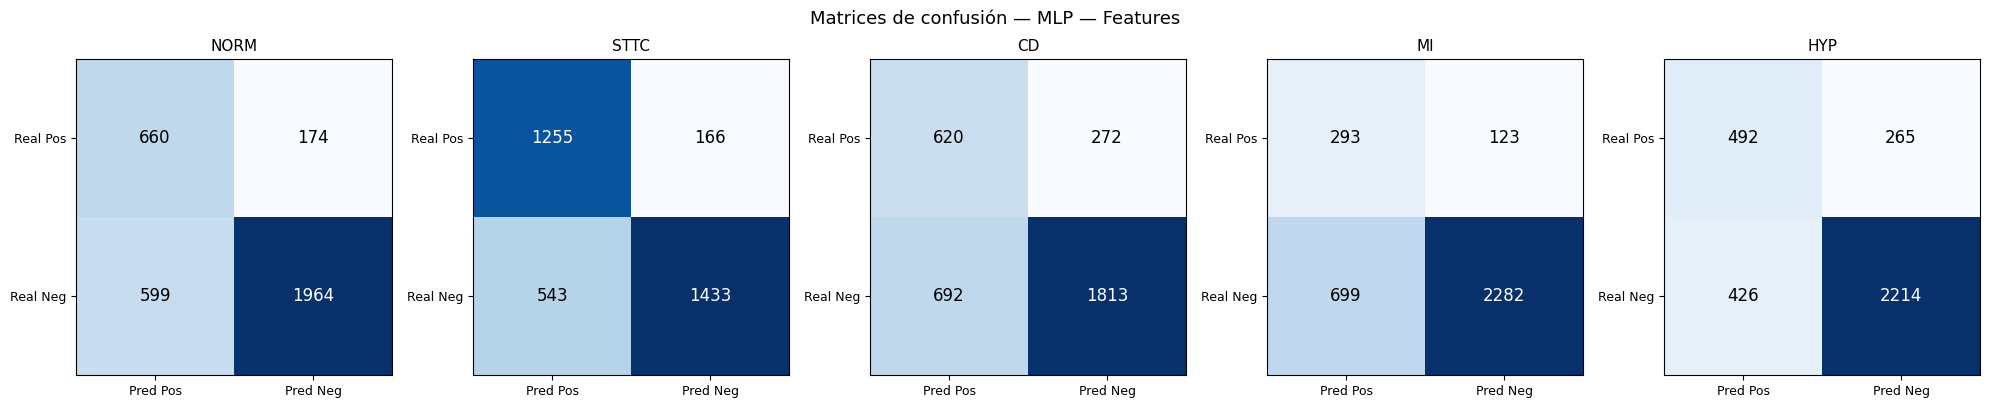


=== MLP — Features_12 ===
  Epoch 10/100 - Pérdida: 0.5721 - lr: 0.001000
  Epoch 20/100 - Pérdida: 0.5247 - lr: 0.001000
  Epoch 30/100 - Pérdida: 0.4894 - lr: 0.001000
  Epoch 40/100 - Pérdida: 0.4623 - lr: 0.001000
  Epoch 50/100 - Pérdida: 0.4382 - lr: 0.001000
  Epoch 60/100 - Pérdida: 0.4266 - lr: 0.001000
  Epoch 70/100 - Pérdida: 0.4064 - lr: 0.001000
  Epoch 80/100 - Pérdida: 0.3924 - lr: 0.001000
  Epoch 90/100 - Pérdida: 0.3636 - lr: 0.000500
  Epoch 100/100 - Pérdida: 0.3446 - lr: 0.000500

--- Train ---
Hamming accuracy (mide el % de etiquetas individuales bien clasificadas):0.9378
              precision    recall  f1-score   support

        NORM       0.77      0.97      0.86      3323
        STTC       0.92      0.98      0.95      5711
          CD       0.78      0.97      0.87      3447
          MI       0.73      1.00      0.85      1729
         HYP       0.80      0.95      0.87      3111

   micro avg       0.82      0.97      0.89     17321
   macro avg     

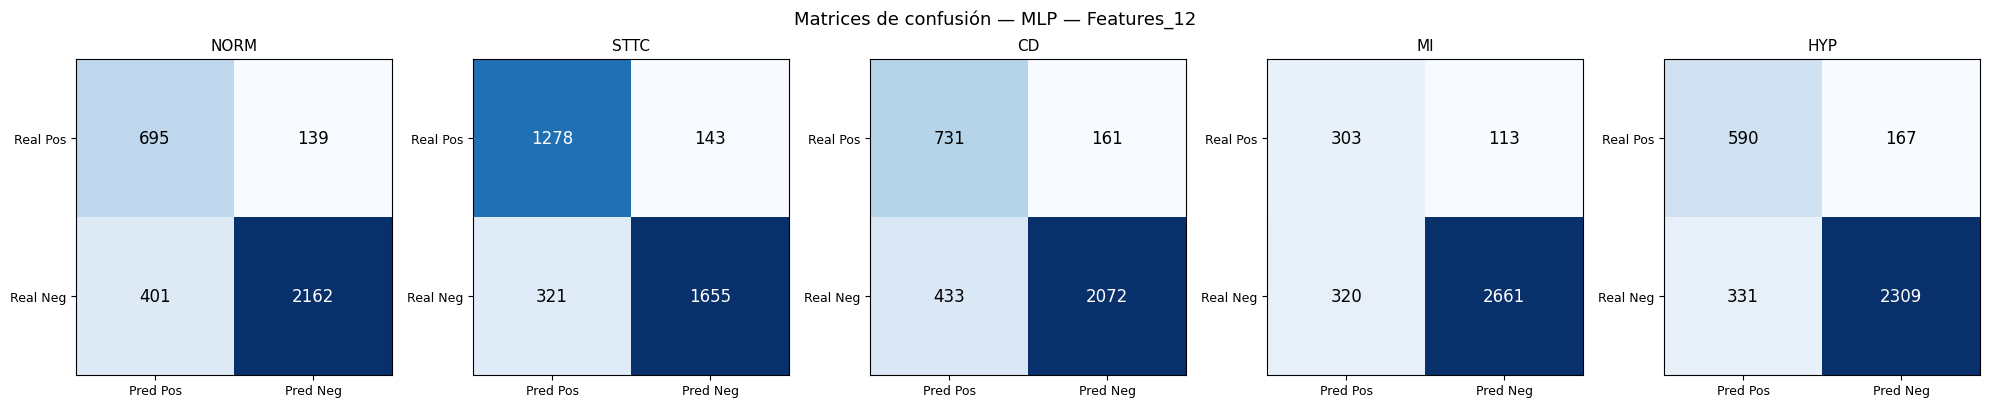

In [113]:
#mlp_raw  = ejecutar_mlp(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
mlp_feat = ejecutar_mlp(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
mlp_feat_12 = ejecutar_mlp(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")